<div style="text-align: center;">
    <a href="https://www.hi-paris.fr/">
        <img border="0" src="https://www.hi-paris.fr/wp-content/uploads/2020/09/logo-hi-paris-retina.png" width="25%"></a>
    <a href="https://www.dataia.eu/">
        <img border="0" src="https://github.com/ramp-kits/template-kit/raw/main/img/DATAIA-h.png" width="70%"></a>
</div>

# Alpine Snow Depth Forecasting — French Alps 🏔️

# Introduction 

The French Alps will host the **2030 Winter Olympics**. In a context of accelerating climate change, snow conditions in mountain regions are increasingly uncertain. This challenge asks you to predict **snow depth 7 days ahead** across the French Alps, using daily meteorological observations from Météo-France's SIM model.

The task is a **Regression**: predict the target variable `HTEURNEIGE_J7` (snow depth in meters at day J+7) for each Alpine grid point, given meteorological observations at day J.

Data comes from **Météo-France's SIM model** (8km resolution). It has been filtered for the French Alps, keeping only grid points that experience snow, and restricted to winter months (October → April).

# Exploratory Data Analysis

The goal of this section is to explore the **Météo-France SIM dataset** and understand its structure. Data exploration is the crucial first step in any data science project. Here, we will give you a sense of the Alpine weather data you will be working with.

We will first load the ~1.2 million rows of training data and describe its features (such as altitude, temperature, and precipitation). Then, we will visualize some interesting properties of the dataset, particularly the distribution of our target variable: **the snow depth 7 days ahead** (`HTEURNEIGE_J7`).

Dimension of X : (700340, 19)
Dimensions of y : (700340, 4)


,LAMBX,LAMBY,DATE,T,TINF_H,TSUP_H,PRENEI,PRELIQ,FF,SSI,DLI,HU,Q,ETP,HTEURNEIGE,RESR_NEIGE,SNOW_FRAC,ECOULEMENT,SWI
0,8040,19050,2020-01-01,1.9,-1.7,7.3,0.0,0.1,0.8,799.6,2904.4,88.1,3.833,1.3,0.0,0.0,0.0,0.0,0.839
1,8040,19050,2020-01-02,2.2,-1.5,5.5,0.0,0.0,0.6,180.8,3142.9,94.8,4.273,0.7,0.0,0.0,0.0,0.0,0.832
2,8040,19050,2020-01-03,8.7,5.1,11.9,0.0,0.0,2.5,455.4,2705.5,78.8,5.464,0.8,0.0,0.0,0.0,0.0,0.825
3,8040,19050,2020-01-04,9.9,8.8,12.2,0.0,0.0,10.4,570.6,2347.6,67.8,5.154,2.7,0.0,0.0,0.0,0.0,0.818
4,8040,19050,2020-01-05,7.0,6.4,9.5,0.0,0.0,10.5,918.2,2340.7,62.5,3.865,3.0,0.0,0.0,0.0,0.0,0.806


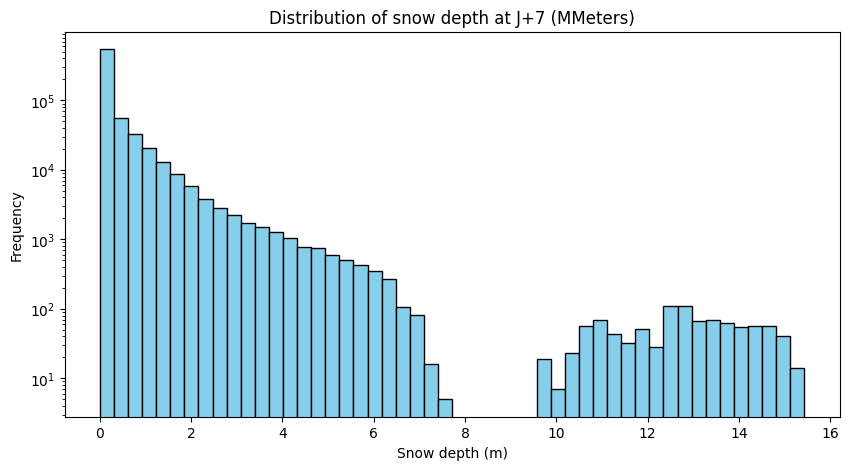

In [11]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

print("Downloading data...")
X_df = pd.read_csv("https://minio.lab.sspcloud.fr/antoinezerrrr/datacamp_meteo/X_train.csv")
y_df = pd.read_csv("https://minio.lab.sspcloud.fr/antoinezerrrr/datacamp_meteo/y_train.csv")
print(f"Dimension of X : {X_df.shape}")
print(f"Dimensions of y : {y_df.shape}")

display(X_df.head())

# Visualisation de la distribution de y
plt.figure(figsize=(10, 5))
plt.hist(y_df['HTEURNEIGE_J7'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of snow depth at J+7 (MMeters)')
plt.xlabel('Snow depth (m)')
plt.ylabel('Frequency')
plt.yscale('log') # Log scale because there are many zeros
plt.show()

# Challenge evaluation

This is a regression task. The model will be evaluated using standard regression metrics, such as **RMSE** (Root Mean Squared Error) and **MAE** (Mean Absolute Error). 
The goal is to be as close as possible to the actual snow depth in meters.


# Submission format

To submit your model to Codabench, you need to provide a Python script (e.g., `submission.py`) containing a function named `get_model()`.

This function must return a **scikit-learn compatible regressor**.



## The submission file

To submit your predictions to Codabench, you must provide a Python script named `submission.py` containing a function called `get_model()`. This function must return an object with `fit()` and `predict()` methods, compatible with the scikit-learn API.

Below is a simple, baseline `submission.py` script. It uses a **Random Forest Regressor** to predict the snow depth (`HTEURNEIGE`) at J+7 based on a predefined set of meteorological features at day J.

Run the cell below. The `%load` command will automatically create the `submission.py` file in your current working directory.

In [8]:
# %load solution/submission.py
from sklearn.ensemble import RandomForestRegressor

# Features available in X_train and X_test
# Feel free to engineer new features on top of these!
FEATURES = [
    "LAMBX", "LAMBY",        # spatial position
    "T", "TINF_H", "TSUP_H", # temperature (mean, min, max)
    "PRENEI", "PRELIQ",       # solid and liquid precipitation
    "FF", "SSI", "DLI",       # wind, visible and atmospheric radiation
    "HU", "Q", "ETP",         # humidity and evapotranspiration
    "HTEURNEIGE", "RESR_NEIGE", "SNOW_FRAC", "ECOULEMENT",  # snow state at day J
    "SWI",                    # soil wetness index
]

# The submission here should simply be a function that returns a model
# compatible with scikit-learn API
def get_model():
    return SnowDepthModel()


class SnowDepthModel:
    """
    Baseline model: Random Forest Regressor.
    Predicts snow depth (HTEURNEIGE) at J+7 from meteorological features at J.

    You can replace this with any model that implements fit() and predict().
    """

    def __init__(self):
        self.model = RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1,
        )

    def fit(self, X, y):
        self.model.fit(X[FEATURES], y)
        return self

    def predict(self, X):
        preds = self.model.predict(X[FEATURES])
        # Snow depth cannot be negative
        return preds.clip(min=0)


# Baseline Model 

Since we don't have the official `X_test.csv` (which is kept hidden on the Codabench server), we will simulate a local testing pipeline.
We will:
1. Split our training data into a local train set and a local validation set.
2. Train a **naive baseline model** (e.g., a standard `RandomForest`) 

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
from solution.submission import get_model # Our model 

X_train_local, X_val_local, y_train_local, y_val_local = train_test_split(
    X_df, 
    y_df['HTEURNEIGE_J7'], # Target variable
    test_size=0.2, 
    random_state=42
)

print(f"Training data : {X_train_local.shape[0]} lines")
print(f"Validation data  : {X_val_local.shape[0]} lines")

model = get_model()

model.fit(X_train_local, np.ravel(y_train_local))

# Prediction 
y_pred_local = model.predict(X_val_local) 

# Evaluation 
rmse = np.sqrt(mean_squared_error(y_val_local, y_pred_local))
mae = mean_absolute_error(y_val_local, y_pred_local)

print("\n" + "="*40)
print(f"RMSE (Root Mean Squared Error) : {rmse:.4f} meters")
print(f"MAE  (Mean Absolute Error)     : {mae:.4f} meters")
print("="*40)

Training data : 560272 lines
Validation data  : 140068 lines

RMSE (Root Mean Squared Error) : 0.1287 meters
MAE  (Mean Absolute Error)     : 0.0493 meters


## Submission

You are now ready to submit to Codabench.

**Steps to submit:**
1. Locate the `submission.py` file that was generated in the same folder as this notebook.
2. Put this `submission.py` file inside a ZIP archive (e.g., `my_submission.zip`).
3. Go to the Codabench challenge page.
4. Navigate to the **"My Submissions"** tab.
5. Click on the upload button, select your ZIP file, and wait for the evaluation server to compute your score

### Ideas to improve the baseline

The baseline Random Forest treats each row independently, ignoring the temporal
and spatial structure of the data. There is significant room for improvement:

- **Feature engineering** — add rolling means, lagged values (J-1, J-2...),
  or interaction terms between temperature and precipitation to give the model
  a short-term weather memory
- **Spatial features** — exploit LAMBX/LAMBY to encode proximity between grid
  points, or derive an implicit altitude proxy from the snow variables themselves
- **Temporal modeling** — use sequence models (LSTM, Transformer) or gradient
  boosting with explicit lag features to capture the autocorrelation in snowpack
  evolution
- **Climate trend** — add `year` or a long-term temperature trend as a feature
  to help the model adapt to the distribution shift between train (2020-2024)
   and test (2025-2026)
- **Zero-snow handling** — the target is zero for a large fraction of samples.
  A two-stage model (classify snow/no-snow, then regress depth) could improve
  performance at high-altitude grid points where predictions matter most